# EDA Posts

### 1. Importación de librerías y lectura de los datos

Entre seis y ocho colores, viridis.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

En primer lugar, después de importar las librerías pertinentes, transformamos los datos XML mediante pandas a un dataframe.

Para la partición, usamos una proporción 80 20 para train y test, respectivamente, para poder hacer un mayor aprovechamiento de los datos en train debido a la gran cantidad de datos de los que disponemos, que seguirá teniendo un test de un tamaño relevante.

Introducimos una semilla para una mayor replicabilidad de ejecución.

In [4]:
np.random.seed(123)
#df = pd.read_xml('../data/raw/Posts.xml')
df = pd.read_pickle("../data/raw/Posts.pkl")
usuariosTrain,usuariosTest = train_test_split(df,test_size=0.3)
df,df_test = train_test_split(df,test_size=0.2)

In [5]:
df.head()

,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,LastEditorUserId,LastEditDate,...,Tags,AnswerCount,CommentCount,ContentLicense,ParentId,LastEditorDisplayName,ClosedDate,FavoriteCount,OwnerDisplayName,CommunityOwnedDate
358021,516285,1,516290.0,2019-10-24T00:45:51.180,2,68.0,<p>I'm looking for a word that means an uncivi...,365304.0,191178.0,2019-10-24T01:11:50.510,...,|single-word-requests|,4.0,1,CC BY-SA 4.0,NaN,None,None,NaN,None,None
268173,368358,2,NaN,2017-01-15T01:11:27.530,0,NaN,<p>I suggest there is no such word.</p>\n\n<p>...,193296.0,NaN,None,...,None,NaN,0,CC BY-SA 3.0,367771.0,None,None,NaN,None,None
262123,358513,1,371220.0,2016-11-15T19:21:22.113,3,1654.0,"<p>In this <a href=""https://youtu.be/q7LwRFhfR...",68054.0,68054.0,2016-11-16T04:32:31.773,...,|slang|phrase-meaning|,2.0,4,CC BY-SA 3.0,NaN,None,None,NaN,None,None
355305,511174,1,NaN,2019-09-10T15:23:38.080,1,56.0,<ol>\n<li><blockquote>\n <p>We are also very ...,359539.0,194281.0,2019-09-10T16:56:42.490,...,|sentence-meaning|,0.0,5,CC BY-SA 4.0,NaN,None,None,NaN,None,None
106016,137695,2,NaN,2013-11-14T17:55:09.437,5,NaN,"<p>How about <strong><em>""<a href=""http://www....",20739.0,NaN,None,...,None,NaN,1,CC BY-SA 3.0,137688.0,None,None,NaN,None,None


En un primer análisis de las observaciones basándonos en las primeras y últimas observaciones del dataset ordenadas según su Id, observamos una desigualdad de denotación de los valores faltantes, en tanto que campos como ParentId o AnswerCount los contemplan como NaN, mientras que LastEditorDisplayName o ClosedDate los contemplan como None. Esto se debe a que aparentemente se ha elegido None para los campos que almacenan strings o fechas, y NaN para los enteros o floats.

En posteriores apartados trataremos este problema para tratar de unificar esta nomenclatura de los faltantes, con el posible estudio de imputaciones de datos.

In [6]:
df.tail()

,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,LastEditorUserId,LastEditDate,...,Tags,AnswerCount,CommentCount,ContentLicense,ParentId,LastEditorDisplayName,ClosedDate,FavoriteCount,OwnerDisplayName,CommunityOwnedDate
36024,41637,2,NaN,2011-09-12T20:44:43.217,11,NaN,<p>I use the word <em>diddle</em> or <em>diddl...,12934.0,NaN,None,...,None,NaN,3,CC BY-SA 3.0,41629.0,None,None,NaN,None,None
317138,450484,2,NaN,2018-06-15T08:54:21.723,1,NaN,<p>It's partly ironic. He is referring to havi...,547.0,NaN,None,...,None,NaN,0,CC BY-SA 4.0,450471.0,None,None,NaN,None,None
66561,78630,1,78662.0,2012-08-17T10:29:12.073,1,1718.0,<p>What does <em>provably good</em> mean ? Do...,24240.0,24240.0,2012-08-17T11:09:08.860,...,|meaning|meaning-in-context|,2.0,4,CC BY-SA 3.0,NaN,None,2012-08-26T15:21:51.237,NaN,None,None
19584,22295,2,NaN,2011-04-23T14:33:44.687,11,NaN,"<p>See <a href=""http://www.etymonline.com/inde...",300.0,NaN,None,...,None,NaN,5,CC BY-SA 3.0,22293.0,None,None,NaN,None,None
423987,617799,1,NaN,2024-01-15T06:57:33.717,5,116.0,<p>Quite a while back I had a language instruc...,496005.0,NaN,None,...,|meaning|,0.0,8,CC BY-SA 4.0,NaN,None,None,NaN,None,None


### 2. Limpieza de datos

#### 2.1 Tratamiento del campo Body

Como se puede observar en la siguiente celda, el campo Body tiene un formato html, por lo que le aplicaremos una transformación para parsear el texto.

In [7]:
df['Body'].head()

358021    <p>I'm looking for a word that means an uncivi...
268173    <p>I suggest there is no such word.</p>\n\n<p>...
262123    <p>In this <a href="https://youtu.be/q7LwRFhfR...
355305    <ol>\n<li><blockquote>\n  <p>We are also very ...
106016    <p>How about <strong><em>"<a href="http://www....
Name: Body, dtype: object

In [8]:
df['Body'] = df['Body'].apply(lambda x: BeautifulSoup(x, "html.parser").get_text().lower() if pd.notna(x) else "")

Se visualiza en la siguiente celda cómo algunos de los cuerpos del post tienen un "\n" dentro de su contenido. Por el momento lo mantendremos por si en futuros apartados lo necesitáramos para dar sentido al texto de alguna forma con los saltos de línea.

In [9]:
df['Body'].head()

358021    i'm looking for a word that means an uncivil a...
268173    i suggest there is no such word.\nany of the a...
262123    in this commercial the lawyer says to a potent...
355305    \n\nwe are also very pleased with a new instal...
106016    how about "unobtrusive"?\nor perhaps "inconspi...
Name: Body, dtype: object

In [10]:
df['Title'].head()

358021    Word that describes an argument but particular...
268173                                                 None
262123    You keep your trap shut and I'll keep your tra...
355305    What does "fights to break out over" and "get ...
106016                                                 None
Name: Title, dtype: object

#### 2.2 Tratamiento del campo Tags

Como se puede observar a continuación, el campo Tags es multivaluado, por lo que puede tomar diferentes valores al mismo tiempo para etiquetar al post. Está en un formato que no es el idóneo para su tratamiento en posteriores análisis, por lo que procedemos a parsearlo.

In [11]:
df["Tags"].tail()

36024                             None
317138                            None
66561     |meaning|meaning-in-context|
19584                             None
423987                       |meaning|
Name: Tags, dtype: object

In [12]:
# Paso 1: Separar las etiquetas en listas
df['Tags'] = df['Tags'].fillna('')  # Rellenar valores NaN con cadenas vacías
df['Tags'] = df['Tags'].apply(lambda x: x.split('|') if x else [])

# Paso 2: Contar todas las etiquetas (total de etiquetas por registro)
from collections import Counter

# Contamos las etiquetas en todos los registros
all_tags = [tag for sublist in df['Tags'] for tag in sublist]
tag_counts = Counter(all_tags)

# Paso 3: Mostrar el número total de etiquetas y las más comunes
print(f"Total de etiquetas en el conjunto de datos: {len(all_tags)}")
print(f"Etiquetas más comunes:")
print(tag_counts.most_common(10))  # Mostrar las 10 etiquetas más frecuentes


Total de etiquetas en el conjunto de datos: 429062
Etiquetas más comunes:
[('', 209242), ('single-word-requests', 16553), ('meaning', 13655), ('grammar', 11128), ('word-choice', 9152), ('word-usage', 7520), ('grammaticality', 4982), ('etymology', 4824), ('phrase-requests', 4685), ('phrases', 4603)]


Se puede observar que la mayoría de posts no tienen tags, y a continuación vemos que hay una gran cantidad de etiquetas únicas, por lo que descartamos para este caso el empleo de one-hot encoding. En este caso comenzaremos por un conteo de frecuencias o count vectorization, como un primer enfoque más simplificado e interpretable. No descartamos en un futuro aplicar otro tipo de transformaciones en embeddings para mejorar la precisión en los modelos a costa de perder la interpretabilidad.

In [13]:
# Número total de etiquetas únicas
unique_tags = len(tag_counts)
print(f"Número de etiquetas únicas: {unique_tags}")

Número de etiquetas únicas: 985


#### 2.3 Tratamiento de los datos faltantes y nulos

Se puede observar en la siguiente celda, cómo algunos campos como *LastEditorDisplayName*, *FavoriteCount* o *CommunityOwnedDate* disponen de un tamaño notablemente más reducido que el de otros campos. Más tarde investigaremos en detalle las causas de este problema.

Cabe destacar que campos como *CommunityOwnedDate* solo aparecen en posts en los que los posts no pertenecen a un solo usuario, no son beneficiosos para un usuario concreto y su propósito es la difusión de contenido colaborativo.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340458 entries, 358021 to 423987
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Id                     340458 non-null  int64  
 1   PostTypeId             340458 non-null  int64  
 2   AcceptedAnswerId       49889 non-null   float64
 3   CreationDate           340458 non-null  object 
 4   Score                  340458 non-null  int64  
 5   ViewCount              104621 non-null  float64
 6   Body                   340458 non-null  object 
 7   OwnerUserId            327522 non-null  float64
 8   LastEditorUserId       144870 non-null  float64
 9   LastEditDate           150437 non-null  object 
 10  LastActivityDate       340458 non-null  object 
 11  Title                  104621 non-null  object 
 12  Tags                   340458 non-null  object 
 13  AnswerCount            104621 non-null  float64
 14  CommentCount           340458 non-nu

A continuación vemos cuáles son los únicos campos que tienen valor para todas las observaciones.

In [15]:
df.columns[df.notna().all()]

Index(['Id', 'PostTypeId', 'CreationDate', 'Score', 'Body', 'LastActivityDate',
       'Tags', 'CommentCount', 'ContentLicense'],
      dtype='object')

A pesar de lo observado anteriormente, ahora al contemplar los tipos de datos de cada campo, hay muchos más campos de texto de los detectados previamente, que corresponden a todos aquellos con tipo "object".

A continuación observamos el rango de cada uno de los campos numéricos. Algo llamativo es que el número de visualizaciones está almacenado como float, al igual que el FavoriteCount, LastEditorUserId, OwnerUserId o AcceptedAnswerId. Mostramos a continuación algunos estadísticos de cada uno de los campos paras obsservar si realmente son floats o si podría deberse a otra causa.

Nuestra primera hipótesis es que esto podría ser debido a que hay muchos NaN en dichos campos, y casualmente los únicos campos que guardan ID que sí que han sido guardados como int son el ID del post y el ID del tipo de post, que son dos de los únicos 7 campos que toman valores para todas las muestras.

Pandas ha introducido en versiones recientes un tipo de dato entero nullable, por lo que en posteriores celdas aplicaremos la correspondiente transformación para conseguir un superior ahorro de memoria.

In [16]:
df[['Score', 'ViewCount', 'AnswerCount', 'CommentCount', 'FavoriteCount', 'LastEditorUserId', 'OwnerUserId', 'AcceptedAnswerId']].describe()

,Score,ViewCount,AnswerCount,CommentCount,FavoriteCount,LastEditorUserId,OwnerUserId,AcceptedAnswerId
count,340458.000000,1.046210e+05,104621.000000,340458.000000,2377.000000,144870.000000,327522.000000,49889.000000
mean,3.397062,9.435738e+03,2.246146,2.226419,0.000421,84005.269228,128404.056894,267544.580549
std,8.591853,3.891288e+04,2.183630,3.109918,0.020511,114996.389860,128400.117680,182139.886118
min,-69.000000,6.000000e+00,0.000000,0.000000,0.000000,-1.000000,-1.000000,12.000000
25%,0.000000,1.880000e+02,1.000000,0.000000,0.000000,2085.000000,19046.000000,102536.000000
50%,1.000000,9.300000e+02,2.000000,1.000000,0.000000,26625.500000,83514.500000,250469.000000
75%,3.000000,4.370000e+03,3.000000,3.000000,0.000000,127726.000000,196354.750000,424241.000000
max,652.000000,2.321634e+06,41.000000,69.000000,1.000000,501000.000000,501000.000000,621008.000000


Aparentemente, al contrario de lo que se podría pensar, FavoriteCount parece indicar si el post ha sido marcado por el usuario como  o no.

In [17]:
df["FavoriteCount"].value_counts()

FavoriteCount
0.0    2376
1.0       1
Name: count, dtype: int64

Comprobamos que realmente los únicos posts que toman valores para FavoriteCounts son los de tipo 1, es decir, las preguntas. Esto es algo muy extraño, y además muy pocos posts están calificados como favoritos. Podríamos inferir que 1 implica que se ha marcado como favorita y 0 lo contrario.

In [18]:
df[df['PostTypeId'] == 1]['FavoriteCount'].notna().sum()

np.int64(2377)

In [19]:
df.isnull().sum()

Id                            0
PostTypeId                    0
AcceptedAnswerId         290569
CreationDate                  0
Score                         0
ViewCount                235837
Body                          0
OwnerUserId               12936
LastEditorUserId         195588
LastEditDate             190021
LastActivityDate              0
Title                    235837
Tags                          0
AnswerCount              235837
CommentCount                  0
ContentLicense                0
ParentId                 105728
LastEditorDisplayName    333788
ClosedDate               312185
FavoriteCount            338081
OwnerDisplayName         326800
CommunityOwnedDate       338947
dtype: int64

Se puede observar a continuación que los valores para los posts que no tienen cuerpo ni título son los siguientes 3 = Orphaned tag wiki, 4 = Tag wiki excerpt y 5 = Tag wiki.

El tipo 3 significa que corresponde a una entrada de wiki de un tag que está "huérfano", lo que significa que o bien ha sido eliminada o que ya no se utiliza. Las wiki son entradas colaborativas que sirven para dar explicaciones sobre tags.

El tipo 4 significa que corresponde a un extracto breve de la etiqueta.

El tipo 5 es el post coipmpleto de la etiqueta, con todo lo que representa. El hecho de que haya tantos posts "vacíos" (sin cuerpo ni título) se debe a que simplemente son explicaciones sobre etiquetas.

In [20]:
df[df["Body"] == ""]["PostTypeId"].value_counts()

PostTypeId
5    198
4     40
3      1
Name: count, dtype: int64

In [21]:
(df[df["Body"] == ""]["Title"].isnull()).count()

np.int64(239)

A continuación analizamos el tipo de contenido que tiene el cuerpo de los posts etiquetados con el tipo 3.

In [22]:
pd.set_option('display.max_colwidth', None)

df[df["PostTypeId"] == 3]["Body"].head()

15847                                                                                                                                                                                                                                                 
3718                                                                                                    questions are now being stripped of this tag, as it is too vague. \nplease do not put it on new questions. \nsee this meta post for details.\n
3886     this tag is for questions about whether a language feature—such as a word, phrase or grammatical construct—is acceptable, correct or common (as opposed to unacceptable, erroneous or obsolete).\nfor further info, see this meta question.\n
3887                                                                                                                                                                         questions about correctness or commonness of a construct, phrase or word.
Name: Body, 

Dado que nuestro objetivo principal se centra en analizar los posts que tienen un texto, y que tengan contenido sustancial del que extraer información, no solo explicaciones o entradas de la wiki que simplemente sirvan como explicaciones de los tags, procederemos a eliminar las muestras que no tengan el campo Body ni Title.

In [23]:
df = df[~(df["Body"].isna() & df["Title"].isna())]

#### 2.5 Tratamiento de los campos de fechas

A continuación, observamos la precisión de las fechas, que están guardados como datos de tipo objeto. La precisión es de milisegundos, pero nosotros optaremos por una reducción de la precisión a segundos, para optimizar el almacenamiento de los mismos sin perder información.

In [24]:
df['CreationDate'].head()

358021    2019-10-24T00:45:51.180
268173    2017-01-15T01:11:27.530
262123    2016-11-15T19:21:22.113
355305    2019-09-10T15:23:38.080
106016    2013-11-14T17:55:09.437
Name: CreationDate, dtype: object

In [25]:
df['CreationDate'] = pd.to_datetime(df['CreationDate']).astype('datetime64[s]')
df['LastActivityDate'] = pd.to_datetime(df['LastActivityDate']).astype('datetime64[s]')
df['LastEditDate'] = pd.to_datetime(df['LastEditDate']).astype('datetime64[s]')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate']).astype('datetime64[s]')
df['CommunityOwnedDate'] = pd.to_datetime(df['CommunityOwnedDate']).astype('datetime64[s]')

#### 2.4 Mejora de la eficiencia y rendimiento

A continuación procederemos a transformar aquellos campos que no requieran tanta memoria como determina su formato. Anteriormente veíamos cómo algunos campos de ID estaban almacenados como float, y determinados campos se almacenaban en formatos mayores a su rango real. Por tanto, para estas primeras etapas procederemos a transformarlo para una optimización de la memoria y rendimiento, a pesar de que en posteriores fases de aplicación de modelos esto no es tan relevante, debido al uso estandarizado de floats en la ejecución de modelos.

En primer lugar, separamos en primer lugar los campos que tienen valores faltantes, a los cuales asignaremos formatos con "int" (i minúscula), y los campos con NaNs, los cuales transformaremos en "Int" (i mayúscula), formato reciente de enteros en pandas que soporta el almacenamiento de NaNs.

In [26]:
# Convertir las columnas a los tipos adecuados
df['Id'] = df['Id'].astype('int32')
df['PostTypeId'] = df['PostTypeId'].astype('int8')
df['Score'] = df['Score'].astype('int16')
df['CommentCount'] = df['CommentCount'].astype('int8')

df['AcceptedAnswerId'] = df['AcceptedAnswerId'].astype('Int32')
df['ViewCount'] = df['ViewCount'].astype('Int32')
df['OwnerUserId'] = df['OwnerUserId'].astype('Int32')
df['LastEditorUserId'] = df['LastEditorUserId'].astype('Int32')
df['AnswerCount'] = df['AnswerCount'].astype('Int8')
df['ParentId'] = df['ParentId'].astype('Int32')
df['FavoriteCount'] = df['FavoriteCount'].astype('Int8')

In [27]:
df['ParentId'].head()

358021      <NA>
268173    367771
262123      <NA>
355305      <NA>
106016    137688
Name: ParentId, dtype: Int32

### 3. Análisis de las variables cuantitativas

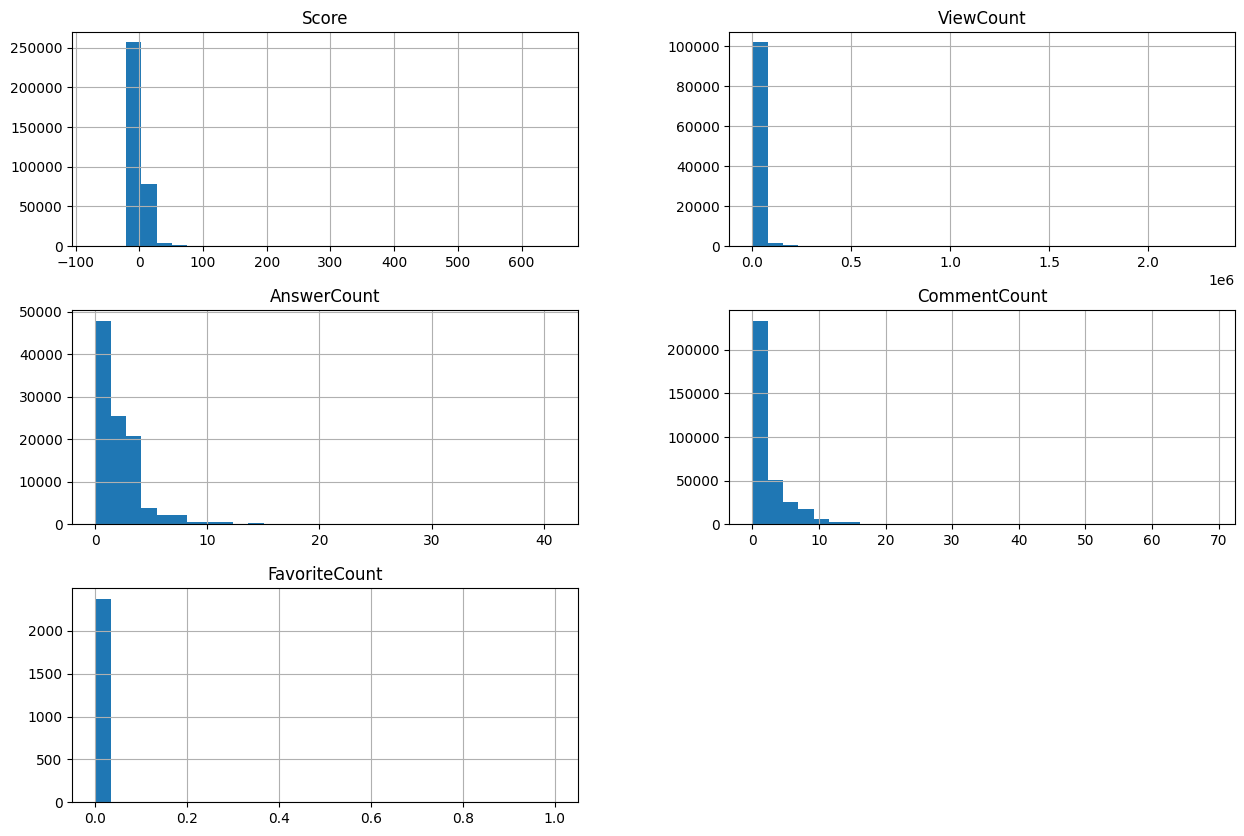

In [28]:
numeric_columns = ['Score', 'ViewCount', 'AnswerCount', 'CommentCount', 'FavoriteCount']
df[numeric_columns].hist(bins=30, figsize=(15, 10))
plt.show()

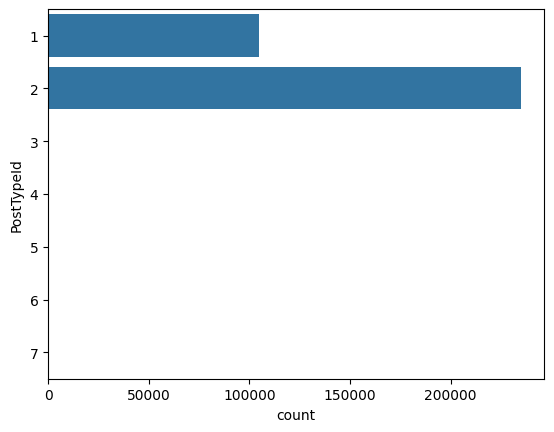

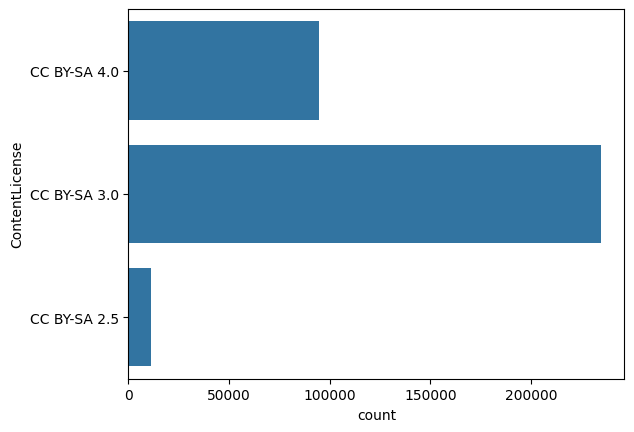

In [29]:
categorical_columns = ['PostTypeId', 'ContentLicense']
for column in categorical_columns:
    sns.countplot(y=column, data=df)
    plt.show()

### Análisis del campo Title

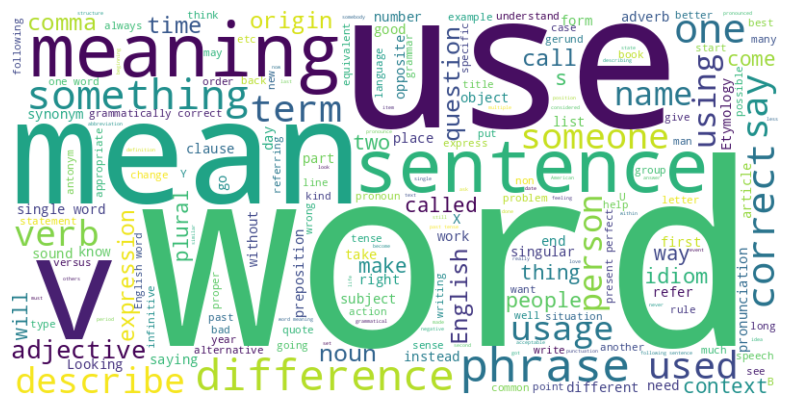

In [30]:
text = ' '.join(df['Title'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Tratamiento de los datos de fechas y transformación

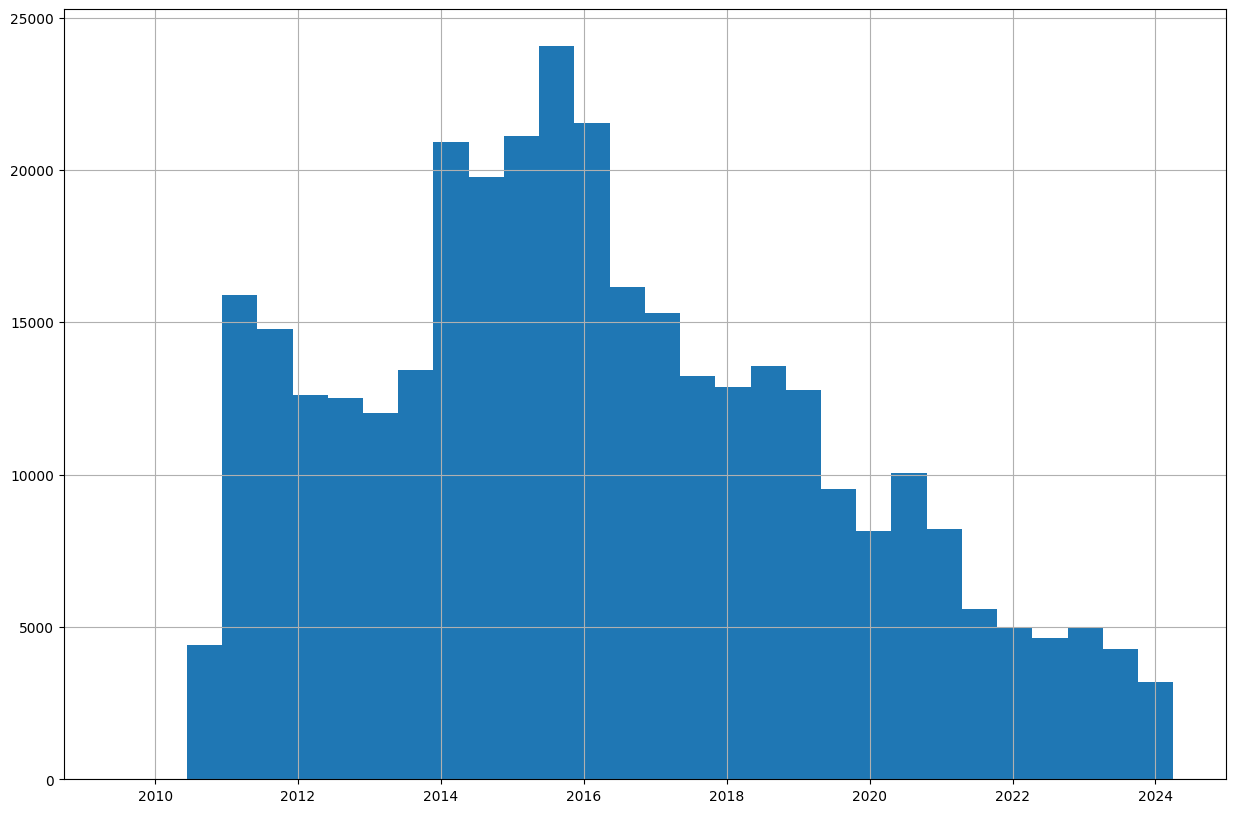

In [31]:
df['CreationDate'].hist(bins=30, figsize=(15, 10))
plt.show()

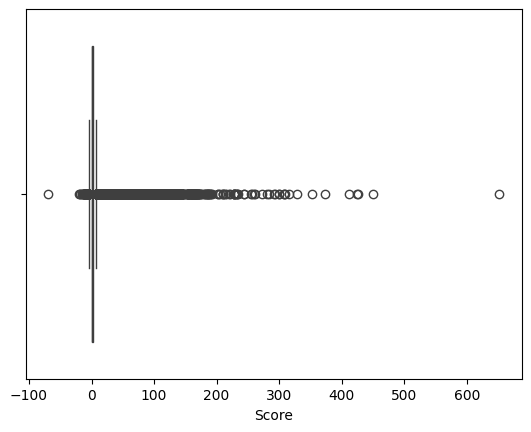

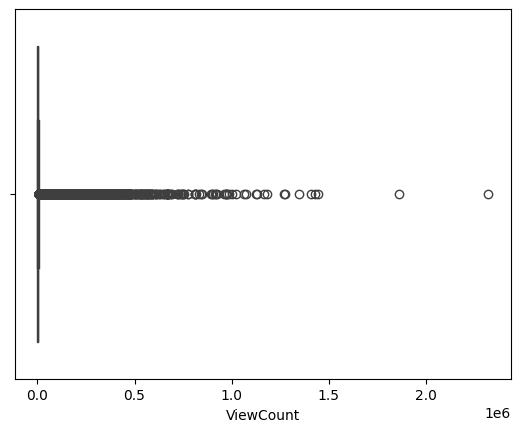

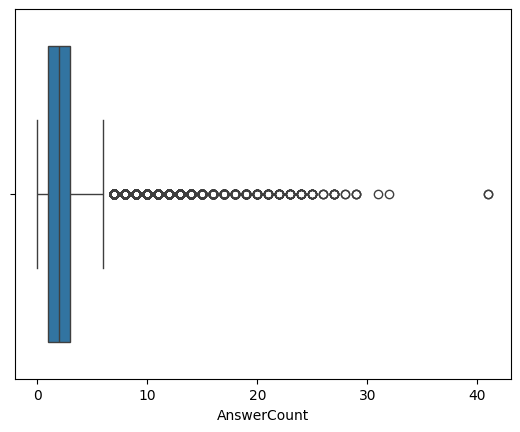

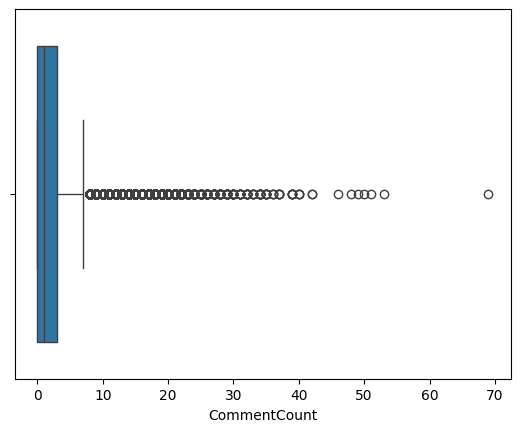

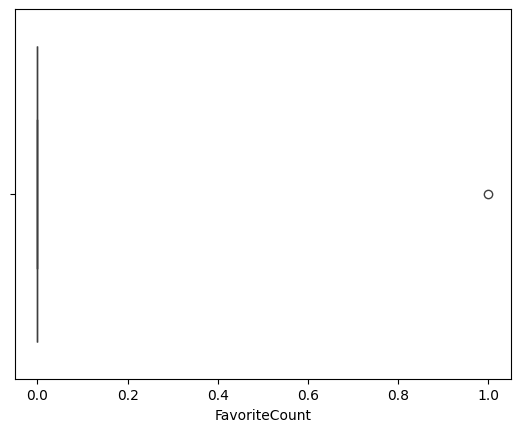

In [32]:
for column in numeric_columns:
    sns.boxplot(x=df[column])
    plt.show()

### 4. Selección de características y PCA

A continuación aplicamos el método de Análisis de Componentes Principales para encontrar cuáles son las variables que recogen la mayor parte de variabilidad de los datos.

In [34]:
# Paso 1: Rellenar o eliminar los NaN (usaremos relleno con la media para las columnas numéricas)
df_filled = df[['Score', 'ViewCount', 'AnswerCount', 'CommentCount', 'FavoriteCount']].fillna(
    df[['Score', 'ViewCount', 'AnswerCount', 'CommentCount', 'FavoriteCount']].mean().astype(int)
)

# Paso 2: Normalización de los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_filled)

# Paso 3: Aplicar PCA
pca = PCA(n_components=2)  # Vamos a reducir a 2 componentes principales para visualizar
pca_result = pca.fit_transform(df_scaled)

# Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])

# Mostrar la varianza explicada por cada componente
print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")

# Mostrar el DataFrame con las 2 primeras componentes principales
print(pca_df.head())


Varianza explicada por cada componente: [0.30691274 0.20187055]
       PCA1      PCA2
0  0.423110 -0.230422
1 -0.536660 -0.570372
2 -0.012110  0.648766
3 -0.963041  1.097722
4 -0.072905 -0.272460
